In [7]:
# Cell 1 — Imports and path setup
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data.load import load_config, load_dataset

# Plot styling
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("husl")

print("✅ Imports OK")

✅ Imports OK


In [9]:
# Cell 2 — Load dataset using load.py
from pathlib import Path

# Resolve project root regardless of where notebook is run from
PROJECT_ROOT = Path("..").resolve()

config = load_config(PROJECT_ROOT / "config/config.yaml")

# Override paths to be absolute
config["dataset"]["raw_path"] = str(PROJECT_ROOT / "data/raw")

train_df, test_df, rul = load_dataset(config)

[load] Train shape : (20631, 26)
[load] Test shape  : (13096, 26)
[load] RUL entries : 100


In [10]:
# Cell 3 - Basic Dataset Inspection
print("=== TRAIN ===")
print(f"Shape     : {train_df.shape}")
print(f"Engines   : { train_df['unit'].nunique()}")
print(f"Cycles range  : {train_df['cycle'].min()} - {train_df['cycle'].max()}")
print(f"Columns  : {list(train_df.columns)}")

print("\n=== TEST ===")
print(f"Shape     : {test_df.shape}")
print(f"Engines   : { test_df['unit'].nunique()}")

print("\n=== RUL ===")
print(f"Min RUL  : {rul.min()}")
print(f"Max RUL  : {rul.max()}")
print(f"Mean RUL : {rul.mean():.1f}")


=== TRAIN ===
Shape     : (20631, 26)
Engines   : 100
Cycles range  : 1 - 362
Columns  : ['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']

=== TEST ===
Shape     : (13096, 26)
Engines   : 100

=== RUL ===
Min RUL  : 7
Max RUL  : 145
Mean RUL : 75.5


=== ENGINE LIFECYCLE STATISTICS ===
Shortest lifespan : 128 cycles
Longest lifespan  : 362 cycles
Mean lifespan     : 206.3 cycles
Median lifespan   : 199.0 cycles
Std deviation     : 46.3 cycles


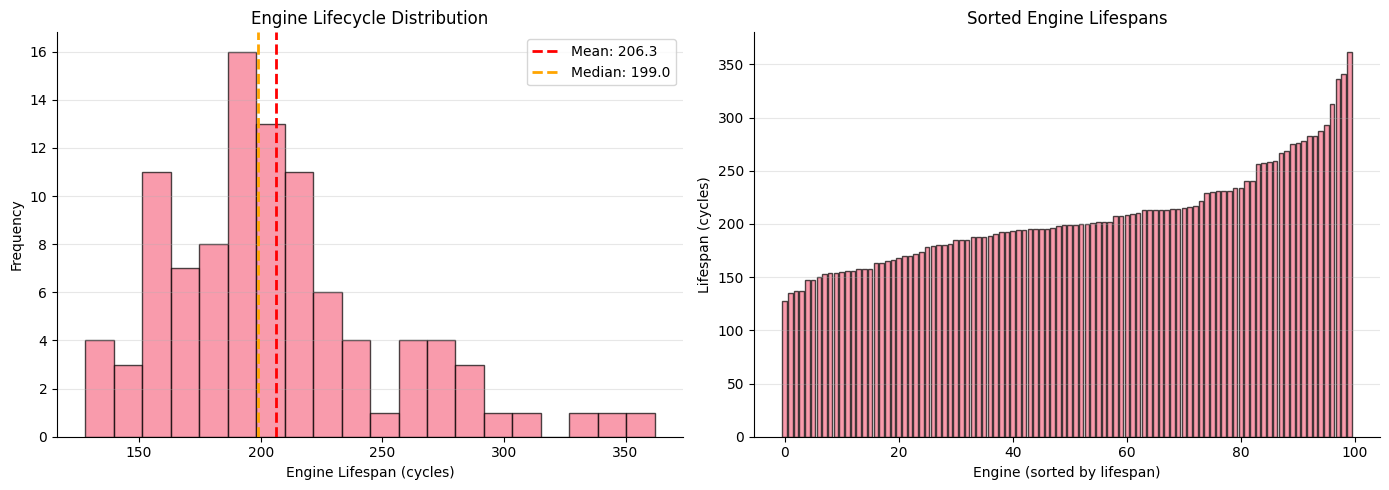


✅ Lifespan range: 234 cycles


In [11]:
# Cell 4 — Engine Lifecycle Distribution
"""
Purpose: Analyze engine lifespan distribution to understand degradation trajectory range.
Why: Knowing lifecycle variability helps set expectations for RUL prediction range.
"""

# Calculate max cycle (lifespan) per engine
engine_lifespans = train_df.groupby("unit")["cycle"].max().sort_values()

print("=== ENGINE LIFECYCLE STATISTICS ===")
print(f"Shortest lifespan : {engine_lifespans.min()} cycles")
print(f"Longest lifespan  : {engine_lifespans.max()} cycles")
print(f"Mean lifespan     : {engine_lifespans.mean():.1f} cycles")
print(f"Median lifespan   : {engine_lifespans.median():.1f} cycles")
print(f"Std deviation     : {engine_lifespans.std():.1f} cycles")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(engine_lifespans, bins=20, edgecolor="black", alpha=0.7)
axes[0].axvline(engine_lifespans.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean: {engine_lifespans.mean():.1f}")
axes[0].axvline(engine_lifespans.median(), color="orange", linestyle="--", linewidth=2, label=f"Median: {engine_lifespans.median():.1f}")
axes[0].set_xlabel("Engine Lifespan (cycles)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Engine Lifecycle Distribution")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Sorted bar chart
axes[1].bar(range(len(engine_lifespans)), engine_lifespans.values, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Engine (sorted by lifespan)")
axes[1].set_ylabel("Lifespan (cycles)")
axes[1].set_title("Sorted Engine Lifespans")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Lifespan range: {engine_lifespans.max() - engine_lifespans.min()} cycles")

=== SENSOR STATISTICS (across all cycles) ===
               mean     std       min       max  variance    range
sensor_1    518.670   0.000   518.670   518.670     0.000    0.000
sensor_2    642.681   0.500   641.210   644.530     0.250    3.320
sensor_3   1590.523   6.131  1571.040  1616.910    37.591   45.870
sensor_4   1408.934   9.001  1382.250  1441.490    81.011   59.240
sensor_5     14.620   0.000    14.620    14.620     0.000    0.000
sensor_6     21.610   0.001    21.600    21.610     0.000    0.010
sensor_7    553.368   0.885   549.850   556.060     0.783    6.210
sensor_8   2388.097   0.071  2387.900  2388.560     0.005    0.660
sensor_9   9065.243  22.083  9021.730  9244.590   487.654  222.860
sensor_10     1.300   0.000     1.300     1.300     0.000    0.000
sensor_11    47.541   0.267    46.850    48.530     0.071    1.680
sensor_12   521.413   0.738   518.690   523.380     0.544    4.690
sensor_13  2388.096   0.072  2387.880  2388.560     0.005    0.680
sensor_14  8143.

/var/folders/60/52ssn0g963lfqt69krdb04840000gn/T/ipykernel_83226/3884454848.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(sensor_ranges_norm.values, labels=sensor_cols, showfliers=False)


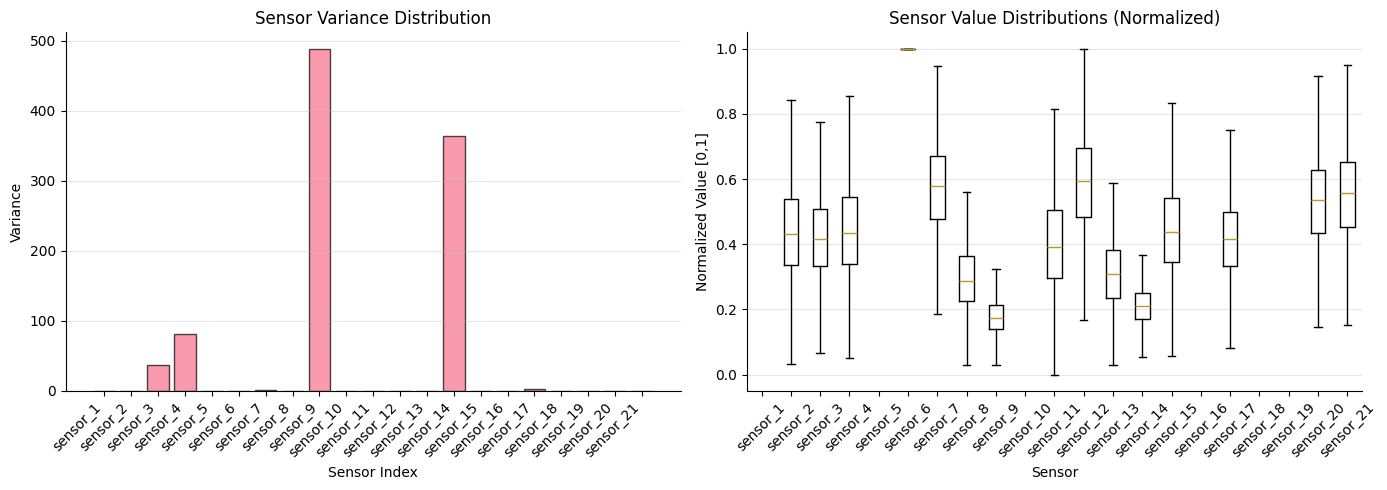

In [12]:
# Cell 5 — Sensor Statistics
"""
Purpose: Analyze sensor ranges and variances to identify informative vs. flat sensors.
Why: Sensors with zero variance provide no predictive signal and should be excluded.
     High variance sensors may indicate degradation patterns.
"""

# Extract sensor columns (exclude unit, cycle, operational settings)
sensor_cols = [col for col in train_df.columns if col.startswith("s")]

# Compute statistics per sensor
sensor_stats = train_df[sensor_cols].describe().T
sensor_stats["variance"] = train_df[sensor_cols].var()
sensor_stats["range"] = sensor_stats["max"] - sensor_stats["min"]

print("=== SENSOR STATISTICS (across all cycles) ===")
print(sensor_stats[["mean", "std", "min", "max", "variance", "range"]].round(3))

# Identify flat sensors (zero or near-zero variance)
flat_threshold = 1e-6
flat_sensors = sensor_stats[sensor_stats["variance"] < flat_threshold].index.tolist()

print(f"\n⚠️  Flat sensors (variance < {flat_threshold}): {flat_sensors}")
print(f"✅ Active sensors: {len(sensor_cols) - len(flat_sensors)} / {len(sensor_cols)}")

# Visualization: Sensor variance distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of sensor variances
axes[0].bar(range(len(sensor_stats)), sensor_stats["variance"].values, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Sensor Index")
axes[0].set_ylabel("Variance")
axes[0].set_title("Sensor Variance Distribution")
axes[0].set_xticks(range(len(sensor_stats)))
axes[0].set_xticklabels(sensor_stats.index, rotation=45, ha="right")
axes[0].grid(axis="y", alpha=0.3)

# Box plot of sensor ranges (normalized)
sensor_ranges_norm = (train_df[sensor_cols] - train_df[sensor_cols].min()) / (train_df[sensor_cols].max() - train_df[sensor_cols].min())
axes[1].boxplot(sensor_ranges_norm.values, labels=sensor_cols, showfliers=False)
axes[1].set_xlabel("Sensor")
axes[1].set_ylabel("Normalized Value [0,1]")
axes[1].set_title("Sensor Value Distributions (Normalized)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

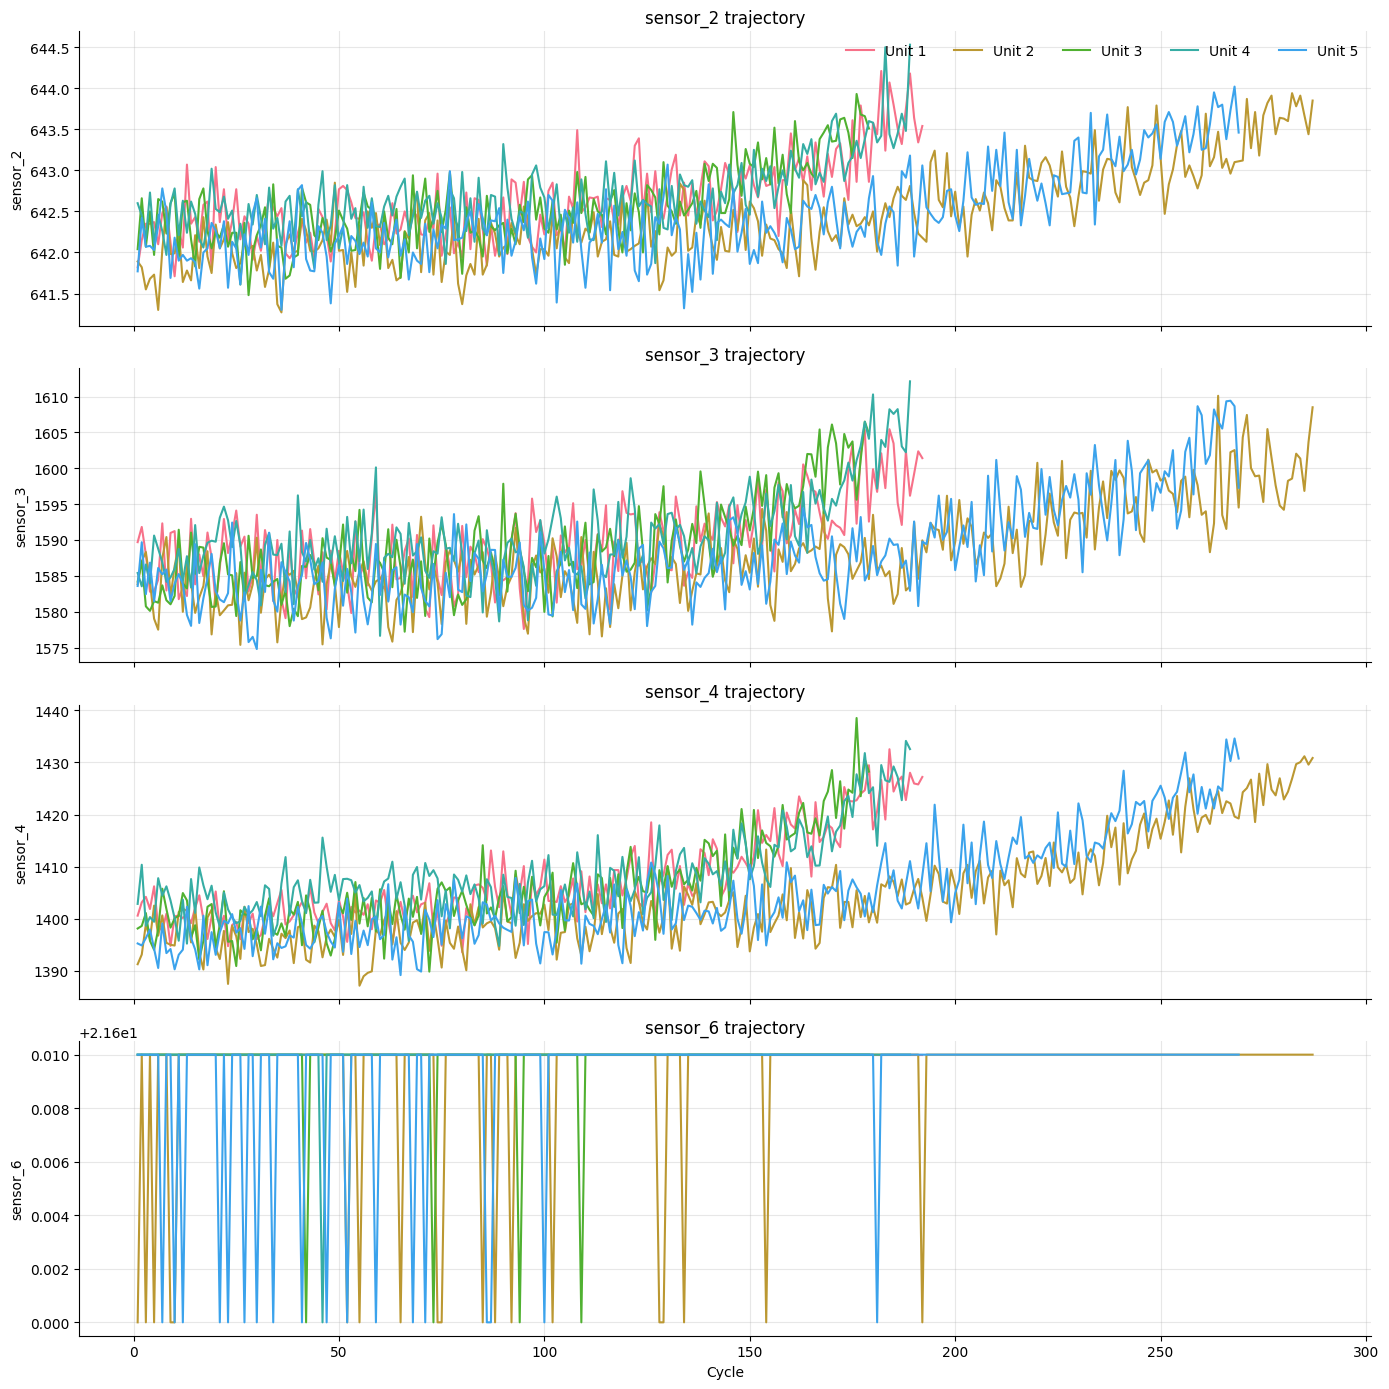

In [19]:
# Cell 6 — Multi-engine Sensor Trajectories
"""
Purpose: Compare degradation trajectories across engines for selected sensors.
Input shape: train_df with columns ['unit', 'cycle', sensor columns], one row per cycle.
Output shape: Matplotlib figure with one subplot per sensor and one line per engine.
Assumptions: 'unit' and 'cycle' exist; sensor columns are prefixed with 's'.
Failure conditions: Raises ValueError if no valid sensors or engines are available.
"""

# 1) Pick 3-5 engine unit numbers to plot
sample_engines = sorted(train_df["unit"].unique())[:5]

# Choose sensors from non-flat set discovered in Cell 5 (fallback: all sensors if flat_sensors not defined)
all_sensor_cols = [col for col in train_df.columns if col.startswith("s")]
non_flat_cols = [s for s in all_sensor_cols if "flat_sensors" not in locals() or s not in flat_sensors]
selected_sensors = non_flat_cols[:4]  # 3-5 sensors can also be used; here 4 sensors

if len(sample_engines) < 3:
    raise ValueError("Need at least 3 engines to compare trajectories.")
if len(selected_sensors) == 0:
    raise ValueError("No sensor columns available for plotting.")

# 4) One subplot per sensor, one line per engine
fig, axes = plt.subplots(len(selected_sensors), 1, figsize=(14, 3.5 * len(selected_sensors)), sharex=True)

# Handle single-sensor case
if len(selected_sensors) == 1:
    axes = [axes]

for i, sensor in enumerate(selected_sensors):
    ax = axes[i]
    for engine in sample_engines:
        # 2) Filter train_df by unit number
        engine_data = train_df[train_df["unit"] == engine].sort_values("cycle")

        # 3) Plot cycle on x-axis, sensor value on y-axis
        ax.plot(engine_data["cycle"], engine_data[sensor], linewidth=1.5, label=f"Unit {engine}")

    ax.set_title(f"{sensor} trajectory")
    ax.set_ylabel(sensor)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Cycle")
axes[0].legend(ncol=min(5, len(sample_engines)), frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
# Cell 7 — Sensor-RUL Correlation Analysis
"""
Purpose: Quantify how strongly each sensor correlates with RUL (degradation sensitivity).
Input shape: train_df with columns ['unit', 'cycle', 'sX' for sensors], one row per cycle.
Output shape: Correlation coefficients (21,), sorted by absolute value.
Assumptions: All 21 sensors are present; unit and cycle are valid.
Failure conditions: Raises ValueError if sensors or RUL cannot be computed.
"""

# 1) Add RUL column to train_df using merge (efficient, no apply+lambda)
max_cycles = train_df.groupby("unit")["cycle"].max().reset_index()
max_cycles.columns = ["unit", "max_cycle"]
train_df_rul = train_df.merge(max_cycles, on="unit")
train_df_rul["rul"] = train_df_rul["max_cycle"] - train_df_rul["cycle"]

# 2) Extract all 21 sensors and compute correlations
all_sensor_cols = [col for col in train_df.columns if col.startswith("s")]
correlations = train_df_rul[all_sensor_cols + ["rul"]].corr()["rul"].drop("rul")

# 3) Sort by absolute correlation (both positive and negative are informative)
correlations_sorted = correlations.sort_values(key=abs, ascending=True)

print("=== SENSOR-RUL CORRELATION ===")
print(correlations_sorted.round(3))
print(f"\nTop 5 degradation-sensitive sensors:")
for sensor, corr in correlations_sorted.abs().nlargest(5).items():
    print(f"  {sensor}: {correlations[sensor]:.3f}")

# 4) Plot horizontal bar chart with color coding (positive=green, negative=red)
fig, ax = plt.subplots(figsize=(10, 8))

colors = ["green" if x > 0 else "red" for x in correlations_sorted.values]
bars = ax.barh(range(len(correlations_sorted)), correlations_sorted.values, color=colors, alpha=0.7, edgecolor="black")

ax.set_yticks(range(len(correlations_sorted)))
ax.set_yticklabels(correlations_sorted.index)
ax.set_xlabel("Correlation with RUL")
ax.set_title("Sensor Degradation Sensitivity (Correlation with RUL)")
ax.axvline(0, color="black", linewidth=0.8)
ax.grid(axis="x", alpha=0.3)

# Add value labels on bars
for i, (sensor, corr) in enumerate(correlations_sorted.items()):
    ax.text(corr + 0.01 if corr > 0 else corr - 0.01, i, f"{corr:.3f}", 
            va="center", ha="left" if corr > 0 else "right", fontsize=9)

plt.tight_layout()
plt.show()